In [ ]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = sns.load_dataset('iris')

In [ ]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df = df[df['species']!="setosa"]

In [ ]:
df['species'].unique()

array(['versicolor', 'virginica'], dtype=object)

In [ ]:
df['species'] = df['species'].map({"setosa":0,"versicolor":1,"virginica":3})

In [ ]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,3
146,6.3,2.5,5.0,1.9,3
147,6.5,3.0,5.2,2.0,3
148,6.2,3.4,5.4,2.3,3


In [ ]:
## feature into indpendent and dependent
X = df.drop(columns="species")
y = df["species"]

In [ ]:
print(X)

     sepal_length  sepal_width  petal_length  petal_width
50            7.0          3.2           4.7          1.4
51            6.4          3.2           4.5          1.5
52            6.9          3.1           4.9          1.5
53            5.5          2.3           4.0          1.3
54            6.5          2.8           4.6          1.5
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[100 rows x 4 columns]


In [ ]:
print(y)

50     1
51     1
52     1
53     1
54     1
      ..
145    3
146    3
147    3
148    3
149    3
Name: species, Length: 100, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
regession = LogisticRegression()
regession

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
from sklearn.model_selection import GridSearchCV
parameter = {"C":[0.5,2,4,3,6,7,9,10,40,45,50],
             "penalty":['l1',"l2","elasticnet"]}
logistic_regrssion = GridSearchCV(regession,parameter,scoring="accuracy",cv=5,verbose=1)
logistic_regrssion.fit(X,y)

Fitting 5 folds for each of 33 candidates, totalling 165 fits


d:\Data_Science\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
110 fits failed out of a total of 165.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
55 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Data_Science\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Data_Science\.venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "d:\Data_Science\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1218, in fit
    solver = _check_solv

,estimator,LogisticRegression()
,param_grid,"{'C': [0.5, 2, ...], 'penalty': ['l1', 'l2', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [ ]:
print(logistic_regrssion.best_params_)
print(logistic_regrssion.best_score_)


{'C': 10, 'penalty': 'l2'}
0.97


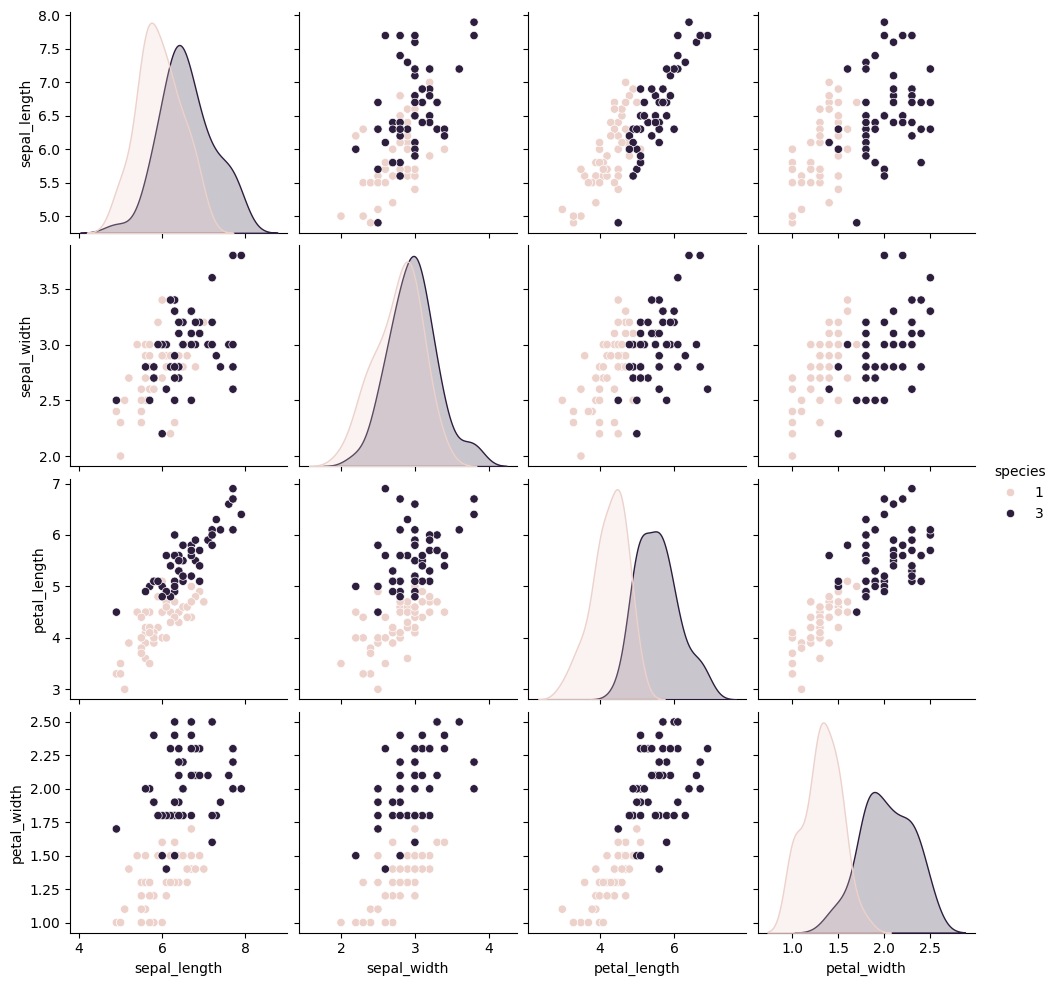

In [ ]:
sns.pairplot(df,hue='species')

In [ ]:
pridection_log = logistic_regrssion.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_recall_curve,roc_auc_score,f1_score


In [ ]:
confusion_matrix(y_test,pridection_log)

array([[16,  1],
       [ 0, 13]])

In [ ]:
f1_score(y_test,pridection_log)

0.9696969696969697

In [ ]:
accuracy_score(y_test,pridection_log)

0.9666666666666667